In [ ]:
from google.colab import files
uploaded = files.upload()


Saving MetaData.csv to MetaData.csv


In [ ]:
import pandas as pd

# Replace with your actual file name if different
df = pd.read_csv("MetaData.csv")

# Check the first few rows
df.head()


,id,gender,age,Area/Location,Infectious Pneumonia,remarks
0,1000,male,31,Karachi,0,normal
1,1001,male,64,Karachi,0,normal
2,1002,male,35,Karachi,0,normal
3,1003,male,32,Karachi,1,"Pneumonia (General) ,CAP (Community-Acquired P..."
4,1004,male,2,Karachi,1,secondary Infectious Pneumonia in the bilater...


<class 'pandas.core.frame.DataFrame'>


/tmp/ipython-input-9-251282941.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=df, ax=axs[0, 0], palette="pastel")
/tmp/ipython-input-9-251282941.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.values, y=location_counts.index, ax=axs[1, 1], palette="viridis")


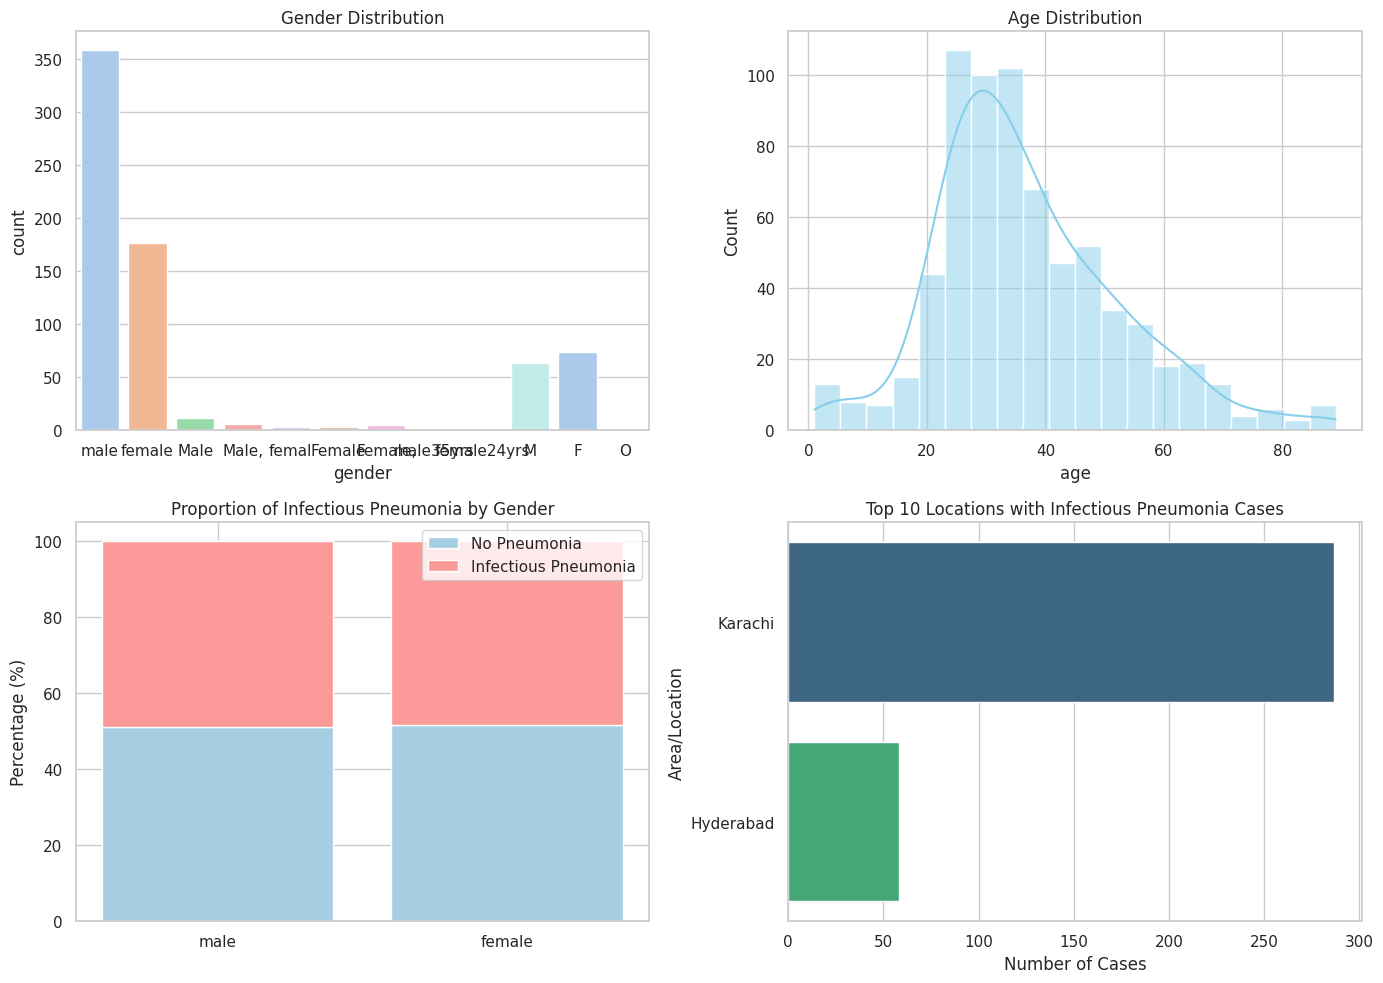

In [ ]:
# Ensure 'age' is numeric
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Check df type if error persists
print(type(df))  # Should be <class 'pandas.core.frame.DataFrame'>

# Clean age column (convert to numeric, coerce errors to NaN)
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Set seaborn style
sns.set(style="whitegrid")

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gender distribution
sns.countplot(x="gender", data=df, ax=axs[0, 0], palette="pastel")
axs[0, 0].set_title("Gender Distribution")

# 2. Age distribution
sns.histplot(df["age"].dropna(), bins=20, kde=True, ax=axs[0, 1], color="skyblue")
axs[0, 1].set_title("Age Distribution")

# 3. Clean Infectious Pneumonia by Gender (Stacked bar)
grouped = df.groupby("gender")["Infectious Pneumonia"].value_counts(normalize=True).unstack().fillna(0) * 100
genders = ["male", "female"]
yes = [grouped.loc[g, 1] if 1 in grouped.columns else 0 for g in genders]
no = [grouped.loc[g, 0] if 0 in grouped.columns else 0 for g in genders]

axs[1, 0].bar(genders, no, label='No Pneumonia', color='#a6cee3')
axs[1, 0].bar(genders, yes, bottom=no, label='Infectious Pneumonia', color='#fb9a99')
axs[1, 0].set_title("Proportion of Infectious Pneumonia by Gender")
axs[1, 0].set_ylabel("Percentage (%)")
axs[1, 0].legend()

# 4. Infectious Pneumonia by Location
location_counts = df.groupby("Area/Location")["Infectious Pneumonia"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=location_counts.values, y=location_counts.index, ax=axs[1, 1], palette="viridis")
axs[1, 1].set_title("Top 10 Locations with Infectious Pneumonia Cases")
axs[1, 1].set_xlabel("Number of Cases")

plt.tight_layout()
plt.show()


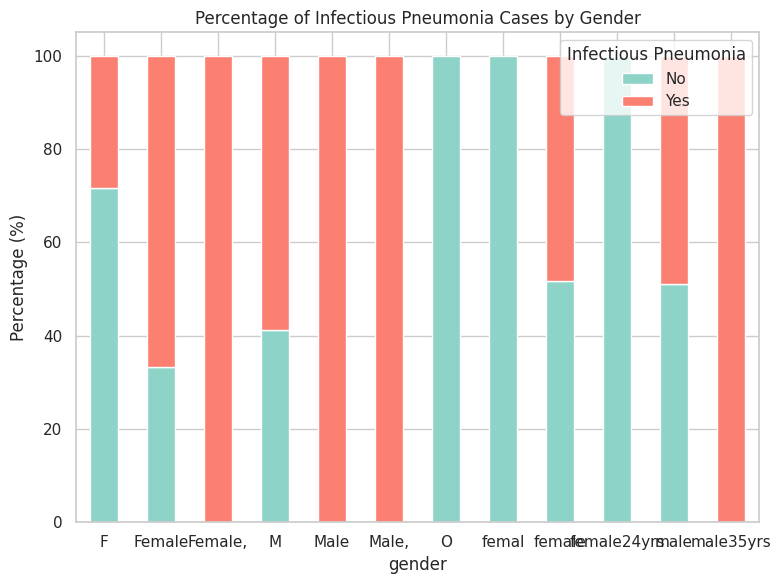

In [ ]:
# Create a new dataframe with percentage of infectious pneumonia cases by gender
gender_pneumonia = df.groupby("gender")["Infectious Pneumonia"].value_counts(normalize=True).unstack() * 100
gender_pneumonia = gender_pneumonia.rename(columns={0: "No", 1: "Yes"})

# Plot as stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
gender_pneumonia.plot(kind="bar", stacked=True, ax=ax, color=["#8dd3c7", "#fb8072"])
ax.set_title("Percentage of Infectious Pneumonia Cases by Gender")
ax.set_ylabel("Percentage (%)")
ax.legend(title="Infectious Pneumonia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


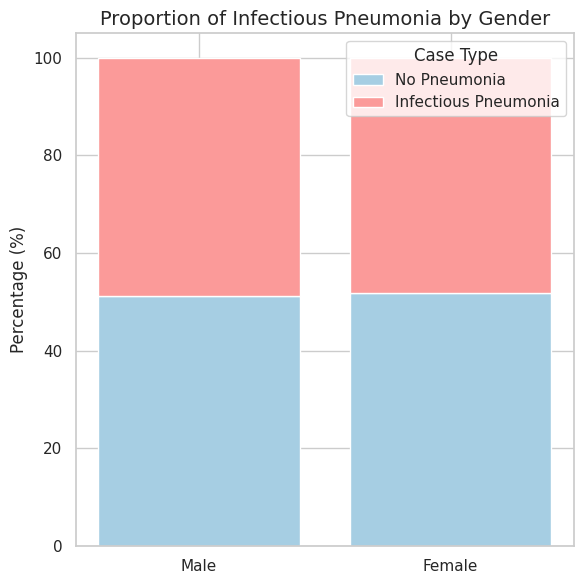

In [ ]:
# Prepare data for clean stacked bar plot with one bar per gender
proportion_data = df.groupby("gender")["Infectious Pneumonia"].value_counts(normalize=True).unstack().fillna(0) * 100
proportion_data = proportion_data.loc[["male", "female"]]  # ensure consistent order
labels = ["No Pneumonia", "Infectious Pneumonia"]

# Plot manually using matplotlib for clean control
fig, ax = plt.subplots(figsize=(6, 6))

# Plot each segment
bottom = [0, 0]  # for stacking
colors = ["#a6cee3", "#fb9a99"]

for i, label in enumerate(labels):
    values = [proportion_data.loc["male", i], proportion_data.loc["female", i]]
    ax.bar(["Male", "Female"], values, bottom=bottom, label=label, color=colors[i])
    bottom = [sum(x) for x in zip(bottom, values)]

# Final touches
ax.set_title("Proportion of Infectious Pneumonia by Gender", fontsize=14)
ax.set_ylabel("Percentage (%)")
ax.legend(title="Case Type")
plt.tight_layout()
plt.show()


/tmp/ipython-input-12-770615027.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_age.index.str.capitalize(), y=avg_age.values, ax=axs[0, 0], palette="coolwarm")
/tmp/ipython-input-12-770615027.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_pneumonia.values, y=location_pneumonia.index, ax=axs[1, 1], palette="mako")


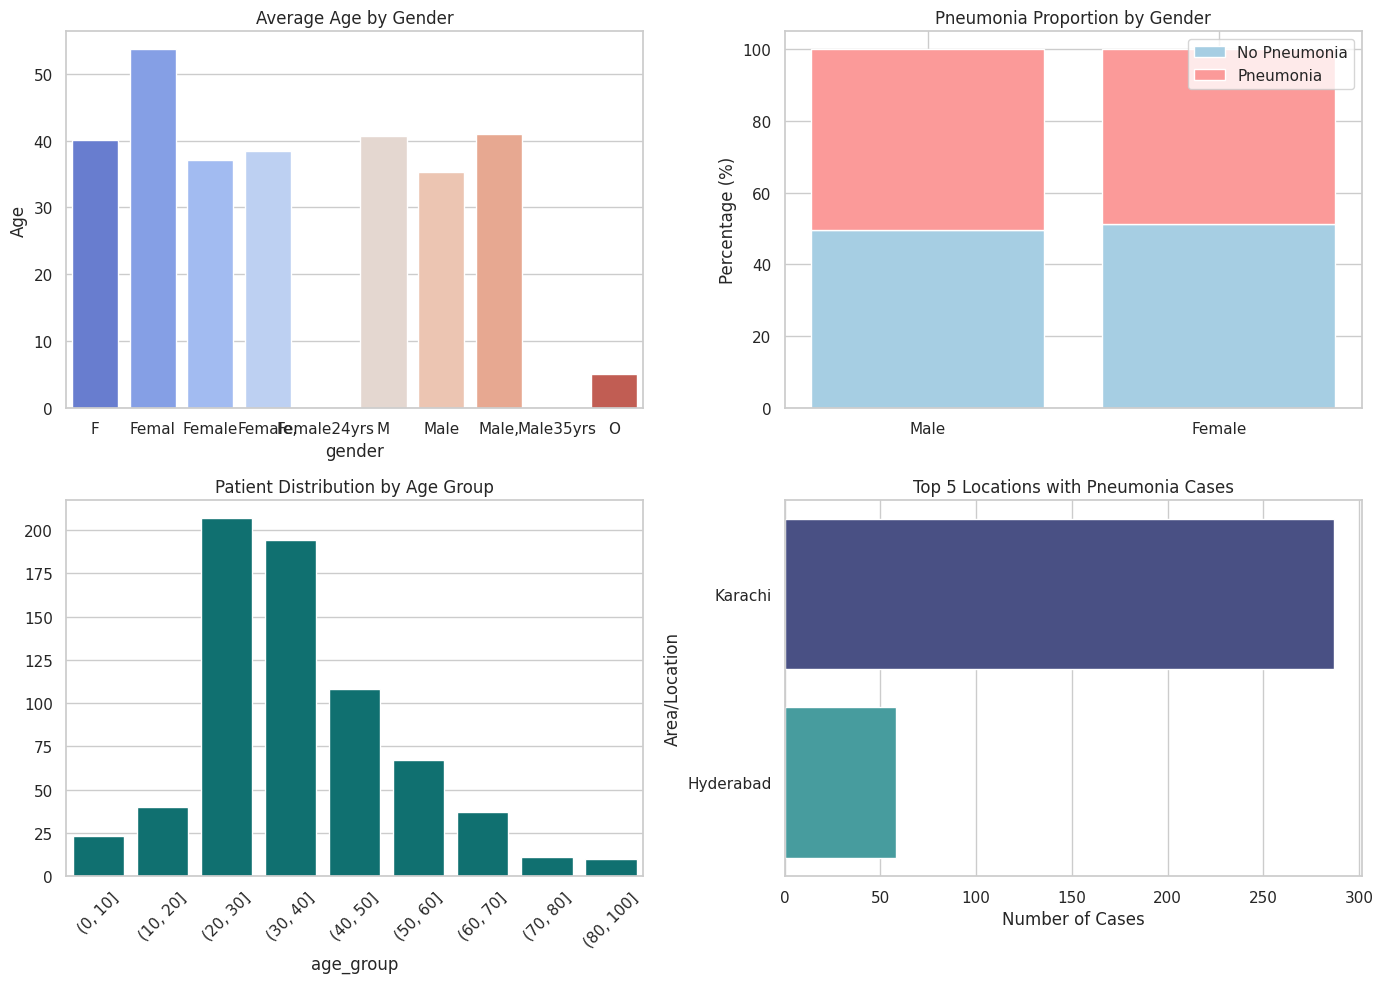

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean the age column
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["gender"] = df["gender"].str.lower().str.strip()

# Setup figure
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
sns.set(style="whitegrid")

# 1. Average Age by Gender
avg_age = df.groupby("gender")["age"].mean()
sns.barplot(x=avg_age.index.str.capitalize(), y=avg_age.values, ax=axs[0, 0], palette="coolwarm")
axs[0, 0].set_title("Average Age by Gender")
axs[0, 0].set_ylabel("Age")

# 2. Pneumonia Proportion by Gender (Stacked)
pneu_dist = df.groupby("gender")["Infectious Pneumonia"].value_counts(normalize=True).unstack().fillna(0) * 100
genders = ["male", "female"]
yes = [pneu_dist.loc[g, 1] if 1 in pneu_dist.columns else 0 for g in genders]
no = [pneu_dist.loc[g, 0] if 0 in pneu_dist.columns else 0 for g in genders]
axs[0, 1].bar(["Male", "Female"], no, label="No Pneumonia", color="#a6cee3")
axs[0, 1].bar(["Male", "Female"], yes, bottom=no, label="Pneumonia", color="#fb9a99")
axs[0, 1].set_title("Pneumonia Proportion by Gender")
axs[0, 1].set_ylabel("Percentage (%)")
axs[0, 1].legend()

# 3. Age Group Distribution
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
df["age_group"] = pd.cut(df["age"], bins)
age_group_dist = df["age_group"].value_counts().sort_index()
sns.barplot(x=age_group_dist.index.astype(str), y=age_group_dist.values, ax=axs[1, 0], color="teal")
axs[1, 0].set_title("Patient Distribution by Age Group")
axs[1, 0].tick_params(axis='x', rotation=45)

# 4. Top 5 Pneumonia Locations
location_pneumonia = df[df["Infectious Pneumonia"] == 1]["Area/Location"].value_counts().head(5)
sns.barplot(x=location_pneumonia.values, y=location_pneumonia.index, ax=axs[1, 1], palette="mako")
axs[1, 1].set_title("Top 5 Locations with Pneumonia Cases")
axs[1, 1].set_xlabel("Number of Cases")

plt.tight_layout()
plt.show()


/tmp/ipython-input-14-3459441152.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["gender_encoded"] = le.fit_transform(df_cleaned["gender"])
/tmp/ipython-input-14-3459441152.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Infectious Pneumonia", data=df_bal, ax=ax[0], palette="Set2")
/tmp/ipython-input-14-3459441152.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["No Pneumonia", "Pneumonia"])


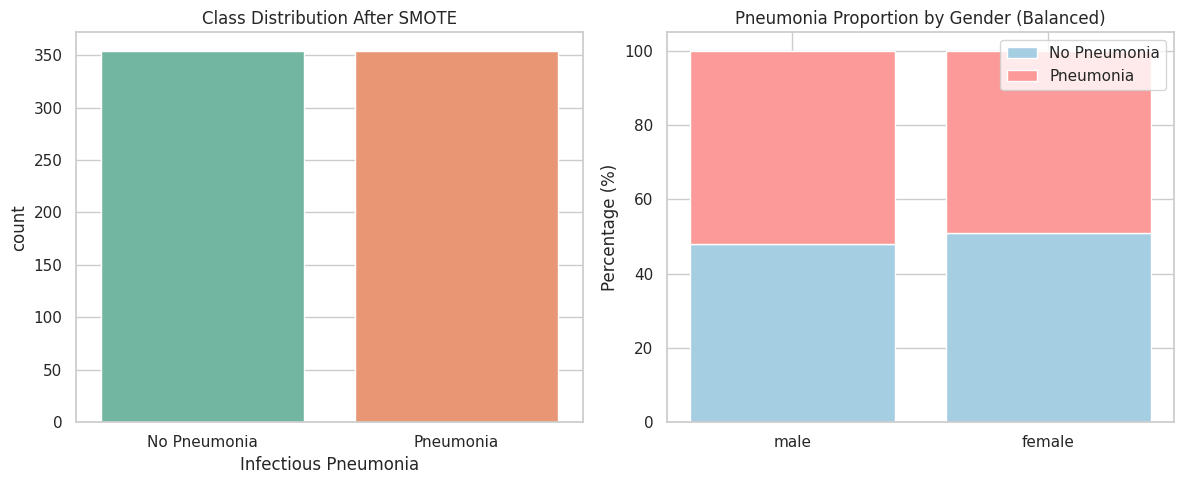

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("MetaData.csv")

# Preprocess
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["gender"] = df["gender"].str.lower().str.strip()
df_cleaned = df.dropna(subset=["age", "gender", "Infectious Pneumonia"])

# Encode gender
le = LabelEncoder()
df_cleaned["gender_encoded"] = le.fit_transform(df_cleaned["gender"])

# Apply SMOTE
X = df_cleaned[["age", "gender_encoded"]]
y = df_cleaned["Infectious Pneumonia"]
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

# Build balanced DataFrame
df_bal = pd.DataFrame(X_resampled, columns=["age", "gender_encoded"])
df_bal["Infectious Pneumonia"] = y_resampled
df_bal["gender"] = le.inverse_transform(df_bal["gender_encoded"].astype(int))

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="Infectious Pneumonia", data=df_bal, ax=ax[0], palette="Set2")
ax[0].set_title("Class Distribution After SMOTE")
ax[0].set_xticklabels(["No Pneumonia", "Pneumonia"])

# Proportion by gender
prop = df_bal.groupby("gender")["Infectious Pneumonia"].value_counts(normalize=True).unstack() * 100
genders = ["male", "female"]
yes = [prop.loc[g, 1] if 1 in prop.columns else 0 for g in genders]
no = [prop.loc[g, 0] if 0 in prop.columns else 0 for g in genders]

ax[1].bar(genders, no, label="No Pneumonia", color="#a6cee3")
ax[1].bar(genders, yes, bottom=no, label="Pneumonia", color="#fb9a99")
ax[1].set_title("Pneumonia Proportion by Gender (Balanced)")
ax[1].legend()
ax[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()
